# 02 - Chat agentico con ricerca web

Finora gli agenti hanno consultato dati locali del lab. Qui costruiamo una chat in cui il modello puo cercare sul web prima di rispondere.

Obiettivo didattico: vedere il flusso `utente -> LLM -> tool web -> LLM -> risposta`, e poi usarlo in un piccolo loop interattivo.

Alla fine saprai:
- creare un tool Python che cerca e legge pagine pubbliche
- collegare il tool a un LLM con `bind_tools`
- costruire un loop LangGraph assistente/tool
- tenere aperta una chat in cui scrivi domande, ricevi risposte e ripeti


## Prerequisiti

Questo notebook usa gli stessi helper dei notebook precedenti:

- `.env` con il provider Ollama gia configurato
- `lab_agentic.utils.get_chat_model`
- `langchain_core` e `langgraph`

Per la ricerca web usiamo solo la libreria standard Python. Non serve una chiave API di ricerca. Questo e comodo per il laboratorio, ma meno robusto di servizi dedicati come Tavily, SerpAPI o Brave Search API.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "lab_agentic").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import re
import textwrap
import urllib.parse
import urllib.request
from dataclasses import dataclass
from html.parser import HTMLParser
from typing import Any

from langchain_core.messages import HumanMessage, SystemMessage
from langchain_core.tools import tool
from langgraph.checkpoint.memory import InMemorySaver
from langgraph.graph import START, MessagesState, StateGraph
from langgraph.prebuilt import ToolNode, tools_condition

from lab_agentic.utils import get_chat_model, load_env

load_env()


## 1. Il modello di chat

Usiamo la stessa funzione helper del corso, cosi il notebook resta coerente con gli altri esempi. La temperatura bassa rende le risposte piu stabili durante il debug.


In [8]:
llm = get_chat_model(provider="ollama", temperature=0)
llm


ChatOllama(disable_streaming='tool_calling', output_version=None, model='llama3.1:8b', temperature=0.0)

## 2. Un mini browser in Python

Un agente non naviga su Internet per magia. Gli serve un tool. Qui lo costruiamo in tre parti:

1. scaricare HTML con `urllib`
2. estrarre link di risultati da DuckDuckGo Lite
3. aprire alcune pagine e trasformarle in testo breve per il modello

Nota pratica: i motori di ricerca possono cambiare HTML o bloccare richieste automatiche. Per una demo didattica va bene; per produzione useremmo una Search API ufficiale.


In [9]:
USER_AGENT = "Mozilla/5.0 (compatible; AgenticAILab/1.0; +https://example.edu)"
REQUEST_TIMEOUT = 12

@dataclass
class SearchResult:
    title: str
    url: str
    snippet: str = ""


def fetch_url(url: str, timeout: int = REQUEST_TIMEOUT) -> str:
    request = urllib.request.Request(url, headers={"User-Agent": USER_AGENT})
    with urllib.request.urlopen(request, timeout=timeout) as response:
        content_type = response.headers.get("content-type", "")
        charset = response.headers.get_content_charset() or "utf-8"
        raw = response.read(1_000_000)
    if "text/html" not in content_type and "text/plain" not in content_type:
        return ""
    return raw.decode(charset, errors="replace")


def clean_space(text: str) -> str:
    return re.sub(r"\s+", " ", text).strip()


class DuckDuckGoLiteParser(HTMLParser):
    def __init__(self):
        super().__init__()
        self.results: list[SearchResult] = []
        self._href: str | None = None
        self._text: list[str] = []

    def handle_starttag(self, tag: str, attrs: list[tuple[str, str | None]]):
        if tag != "a":
            return
        href = dict(attrs).get("href")
        if not href:
            return
        if "uddg=" in href or href.startswith("http"):
            self._href = href
            self._text = []

    def handle_data(self, data: str):
        if self._href is not None:
            self._text.append(data)

    def handle_endtag(self, tag: str):
        if tag != "a" or self._href is None:
            return
        title = clean_space(" ".join(self._text))
        url = normalize_duckduckgo_url(self._href)
        self._href = None
        self._text = []
        if not title or not url.startswith(("http://", "https://")):
            return
        if "duckduckgo.com" in urllib.parse.urlparse(url).netloc:
            return
        if all(existing.url != url for existing in self.results):
            self.results.append(SearchResult(title=title, url=url))


def normalize_duckduckgo_url(href: str) -> str:
    if href.startswith("//"):
        href = "https:" + href
    elif href.startswith("/"):
        href = "https://duckduckgo.com" + href
    parsed = urllib.parse.urlparse(href)
    query = urllib.parse.parse_qs(parsed.query)
    if "uddg" in query:
        return query["uddg"][0]
    return href


def duckduckgo_search(query: str, max_results: int = 5) -> list[SearchResult]:
    search_url = "https://lite.duckduckgo.com/lite/?" + urllib.parse.urlencode({"q": query})
    html = fetch_url(search_url)
    parser = DuckDuckGoLiteParser()
    parser.feed(html)
    return parser.results[:max_results]


## 3. Estrarre testo leggibile dalle pagine

Il modello non ha bisogno dell'intera pagina. Gli passiamo titolo, URL e un estratto compatto. Questo riduce rumore e token.


In [10]:
class PageTextParser(HTMLParser):
    def __init__(self):
        super().__init__()
        self.title: list[str] = []
        self.text: list[str] = []
        self._in_title = False
        self._skip_depth = 0

    def handle_starttag(self, tag: str, attrs: list[tuple[str, str | None]]):
        if tag == "title":
            self._in_title = True
        if tag in {"script", "style", "noscript", "svg"}:
            self._skip_depth += 1
        if tag in {"p", "li", "h1", "h2", "h3", "article", "section", "br"}:
            self.text.append("\n")

    def handle_endtag(self, tag: str):
        if tag == "title":
            self._in_title = False
        if tag in {"script", "style", "noscript", "svg"} and self._skip_depth:
            self._skip_depth -= 1

    def handle_data(self, data: str):
        if self._skip_depth:
            return
        data = clean_space(data)
        if not data:
            return
        if self._in_title:
            self.title.append(data)
        else:
            self.text.append(data)


def html_to_text(html: str) -> dict[str, str]:
    parser = PageTextParser()
    parser.feed(html)
    title = clean_space(" ".join(parser.title))
    text = clean_space(" ".join(parser.text))
    return {"title": title, "text": text}


def trim(text: str, max_chars: int = 1400) -> str:
    text = clean_space(text)
    if len(text) <= max_chars:
        return text
    return text[:max_chars].rsplit(" ", 1)[0] + " ..."


def fetch_page_text(url: str, max_chars: int = 1400) -> dict[str, str]:
    parsed = urllib.parse.urlparse(url)
    if parsed.scheme not in {"http", "https"}:
        return {"title": "", "text": "URL non supportato"}
    html = fetch_url(url)
    parsed_page = html_to_text(html)
    parsed_page["text"] = trim(parsed_page["text"], max_chars=max_chars)
    return parsed_page


## 4. Trasformare il browser in un tool

Il tool `web_research` fa due cose: cerca risultati e apre le prime pagine. Restituisce un testo con fonti numerate, cosi il modello puo citare da dove arrivano le informazioni.


In [11]:
@tool
def web_research(query: str, max_results: int = 3) -> str:
    """Search the public web and return short excerpts with source URLs for answering current questions."""
    try:
        results = duckduckgo_search(query, max_results=max_results)
    except Exception as exc:
        return f"Search failed: {type(exc).__name__}: {exc}"

    if not results:
        return "No web results found. Try a more specific query."

    blocks = []
    for i, result in enumerate(results, start=1):
        try:
            page = fetch_page_text(result.url)
            title = page["title"] or result.title
            excerpt = page["text"] or result.snippet or "No readable text extracted."
        except Exception as exc:
            title = result.title
            excerpt = f"Could not fetch page text: {type(exc).__name__}: {exc}"
        blocks.append(
            f"[{i}] {title}\n"
            f"URL: {result.url}\n"
            f"Excerpt: {excerpt}"
        )
    return "\n\n".join(blocks)


WEB_TOOLS = [web_research]
print(web_research.name)
print(web_research.description)


web_research
Search the public web and return short excerpts with source URLs for answering current questions.


## 5. Testare il tool senza agente

Prima regola pratica: se il tool non funziona da solo, dentro un agente sara solo piu difficile da debuggare.

La cella sotto fa una vera richiesta Internet. Se la rete dell'aula o il motore di ricerca blocca la chiamata, il resto della struttura resta valido, ma dovrai usare una Search API o riprovare con una rete diversa.


In [12]:
print(web_research.invoke({"query": "LangGraph tool calling documentation", "max_results": 2})[:2500])


[1] Tools - Docs by LangChain
URL: https://docs.langchain.com/oss/python/langchain/tools
Excerpt: Skip to main content Join us May 13th & May 14th at Interrupt, the Agent Conference by LangChain. Buy tickets > Docs by LangChain home page Open source Search... ⌘ K Ask AI GitHub Try LangSmith Try LangSmith Search... Navigation Core components Tools Deep Agents LangChain LangGraph Integrations Learn Reference Contribute Python Overview Get started Install Quickstart Changelog Philosophy Core components Agents Models Messages Tools Short-term memory Event streaming Streaming Structured output Middleware Overview Prebuilt middleware Custom middleware Frontend Overview Patterns Integrations Advanced usage Guardrails Runtime Context engineering Model Context Protocol (MCP) Human-in-the-loop Multi-agent Retrieval Long-term memory Agent development LangSmith Studio Test Agent Chat UI Deploy with LangSmith Deployment Observability On this page Create tools Basic tool definition Customize tool pr

## 6. Far decidere al modello quando cercare

`bind_tools` mostra al modello lo schema del tool, ma non lo esegue. Come nei notebook precedenti, serve un loop: il modello chiede un tool, il nodo tool lo esegue, poi il modello produce la risposta finale.


In [ ]:
llm_with_web = llm.bind_tools(WEB_TOOLS)

WEB_SYSTEM = SystemMessage(content=(
    "Se la domanda richiede informazioni recenti, specifiche o verificabili online, "
    "usa il tool web_research prima di rispondere. Rispondi in italiano. "
    "Quando usi il web, cita le fonti con numeri come [1], [2] e includi gli URL usati. "
    "Se il tool non trova risultati o fallisce, dillo chiaramente e separa i fatti verificati dalle ipotesi."
))

probe = llm_with_web.invoke([
    WEB_SYSTEM,
    HumanMessage(content="Quali sono le ultime novita principali su LangGraph? Cerca online e riassumi."),
])

print("Content:", probe.content)
print("Tool calls:", probe.tool_calls)

Tool calls: [{'name': 'web_research', 'args': {'max_results': 5, 'query': 'ultime notizie su LangGraph'}, 'id': '41f1dea6-b9ab-40dc-aca0-8b40b3a24487', 'type': 'tool_call'}]
Content: 


## 7. Il grafo agentico web

Il grafo e volutamente piccolo:

- `assistant`: chiama il modello con il system prompt
- `tools`: esegue `web_research` quando il modello lo chiede
- arco condizionale: decide se fermarsi o andare ai tool
- arco di ritorno: dopo il tool, torna all'assistente per scrivere la risposta finale


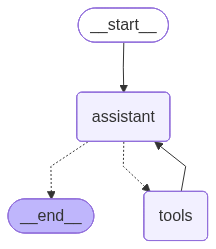

In [14]:
# Il modello non ha memoria di alcun tipo. 
# Quello che dobbiamo fare è creare una vera e propria working memory
def web_assistant(state: MessagesState):
    response = llm_with_web.invoke([WEB_SYSTEM] + state["messages"])
    return {"messages": [response]}


builder = StateGraph(MessagesState)
builder.add_node("assistant", web_assistant)
builder.add_node("tools", ToolNode(WEB_TOOLS))
builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")

web_graph = builder.compile(checkpointer=InMemorySaver())
web_graph


## 8. Provare una singola domanda

Usiamo un `thread_id` per mantenere la memoria conversazionale. Questo permette domande successive come "approfondisci il secondo punto".


In [ ]:
# Il grafo potrebbe essere usato da più utenti. Se noi ci parliamo e gli diciamo qualcosa, un altro utente non deve saperne i dettagli.
# Il thread_id si assegna ad ogni "utente". LangGraph è come se si tenesse un dizionario 
# key = thread_id e value = working memory
config = {"configurable": {"thread_id": "web-agent-demo"}}

result = web_graph.invoke(
    {"messages": [HumanMessage(content="Cerca sul web e spiegami cos'e LangGraph in 5 righe.")]},
    config=config,
)

print(result["messages"][-1].content)


LangGraph è un framework di orchestrazione degli agenti per l'intelligenza artificiale che consente di creare agenti affidabili e personalizzati. E' possibile utilizzare LangGraph per costruire agenti che possano eseguire compiti complessi, come ad esempio la risoluzione di problemi o la generazione di testo. Il framework fornisce una serie di funzionalità, tra cui la possibilità di aggiungere controlli umani in linea e la persistenza della memoria degli agenti.

Per costruire un agente con LangGraph, è necessario seguire i seguenti passaggi:

1. Installare il framework LangGraph e creare la struttura del progetto.
2. Definire lo schema dello stato dell'agente.
3. Creare gli strumenti per l'agente.
4. Costruire le nodi della rete di agenti.
5. Collegare i nodi con condizioni edili.
6. Eseguire l'agente e gestire l'output in streaming.
7. Aggiungere la persistenza della memoria degli agenti con il checkpointing.
8. Implementare i controlli umani in linea.

LangGraph è un framework open-

## 9. Ispezionare cosa e successo

Quando un agente usa tool, lo stato contiene messaggi tecnici: richiesta del tool, risultato del tool e risposta finale. Guardarli aiuta a capire se il modello ha cercato davvero o ha risposto a memoria.


In [16]:
for message in result["messages"]:
    print(type(message).__name__)
    if getattr(message, "tool_calls", None):
        print("tool_calls:", message.tool_calls)
    content = getattr(message, "content", "")
    print(textwrap.shorten(str(content), width=700, placeholder=" ..."))
    print("-" * 80)


HumanMessage
Cerca sul web e spiegami cos'e LangGraph in 5 righe.
--------------------------------------------------------------------------------
AIMessage
tool_calls: [{'name': 'web_research', 'args': {'max_results': 5, 'query': 'LangGraph'}, 'id': '8974a11c-e4ed-4a20-911d-7531db5176e3', 'type': 'tool_call'}]

--------------------------------------------------------------------------------
ToolMessage
[1] LangGraph: Agent Orchestration Framework for Reliable AI Agents URL: https://www.langchain.com/langgraph Excerpt: Products LangSmith Platform Observability See exactly what your agents are doing Evaluation Score and improve agent performance Deployment Ship and scale agents in production Fleet Agents for the whole company Sandboxes Run agent-generated code safely Open Source Frameworks deepagents Build long-running agents for complex tasks langchain Quick start agents with any model provider langgraph Build reliable agents with low-level control Learn Resources Blog Customer Stories

## 10. Chat interattiva in loop

Questa e la parte utile in aula: esegui la cella, scrivi una domanda, leggi la risposta, poi fai un'altra domanda. Scrivi `exit` per uscire.

In Jupyter, un loop con `input()` blocca la cella finche non termini la conversazione.


In [17]:
def web_chat_loop(thread_id: str = "web-chat-loop") -> None:
    config = {"configurable": {"thread_id": thread_id}}
    print("Chat web agentica. Scrivi 'exit' per uscire.\n")

    while True:
        question = input("Tu: ").strip()
        if question.lower() in {"exit", "quit", "q", ""}:
            print("Fine chat.")
            break

        result = web_graph.invoke(
            {"messages": [HumanMessage(content=question)]},
            config=config,
        )
        answer = result["messages"][-1].content
        print("\nAgente:\n" + answer + "\n")


web_chat_loop()


Chat web agentica. Scrivi 'exit' per uscire.


Agente:
Angelo Ferrando è un ricercatore e professore associato presso l'Università di Modena e Reggio Emilia. Ha lavorato come research fellow all'Università di Genova e come postdoctoral research associate all'Università di Manchester e all'Università di Liverpool. Le sue aree di ricerca includono metodi formali, verificazione in esecuzione, ingegneria del software e sistemi multi-agente.

Ha pubblicato articoli su riviste accademiche come Google Scholar e ha presentato lavori a conferenze internazionali come ECOOP 2026. È anche attivo sulla piattaforma GitHub, dove condivide il suo codice e collabora con altri ricercatori.

Inoltre, Angelo Ferrando è presente su LinkedIn e ha un profilo professionale che descrive la sua esperienza lavorativa e le sue aree di ricerca.

Fine chat.


## Esercizio

Modifica il comportamento dell'agente in uno di questi modi:

1. cambia il system prompt per obbligare sempre almeno una ricerca web
2. aumenta `max_results` nel tool
3. aggiungi una regola: se la domanda contiene "oggi", "latest" o "ultime", il modello deve cercare

Poi prova con due domande:

- una domanda stabile, per esempio "che cos'e il tool calling?"
- una domanda temporale, per esempio "quali sono le novita piu recenti su un modello open source?"


In [24]:
# Spazio di lavoro per l'esercizio.
# Esempio: crea un nuovo SystemMessage piu aggressivo sulla ricerca web.

STRICT_WEB_SYSTEM = SystemMessage(content=(
    "Rispondi in italiano. Per ogni domanda che riguarda fatti esterni al corso, "
    "usa web_research prima di rispondere e cita le fonti."
))


## Pitfall e prossimi passi

Pitfall principale: confondere "il modello ha risposto bene" con "il modello ha navigato". Controlla sempre `tool_calls` e i `ToolMessage` quando stai debuggando.

Estensione naturale: sostituire DuckDuckGo Lite con una Search API ufficiale. Il resto del grafo non cambia: cambiano solo le righe dentro `web_research`.
